In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
monthly_df = pd.read_csv(
    "data/processed/monthly_passenger_demand.csv"
)

monthly_df["Month"] = pd.to_datetime(monthly_df["Month"])

monthly_df = monthly_df.sort_values("Month").reset_index(drop=True)

monthly_df.head()

,Month,Passenger Count
0,1999-07-01,3976746
1,1999-08-01,3972694
2,1999-09-01,3341964
3,1999-10-01,3468846
4,1999-11-01,3145240


In [3]:
monthly_df["Lag_1"] = (
    monthly_df["Passenger Count"].shift(1)
)

In [4]:
monthly_df["Lag_2"] = (
    monthly_df["Passenger Count"].shift(2)
)

In [5]:
monthly_df["Lag_12"] = (
    monthly_df["Passenger Count"].shift(12)
)

In [6]:
monthly_df["Rolling_Mean_3"] = (
    monthly_df["Passenger Count"]
    .shift(1)
    .rolling(3)
    .mean()
)

In [7]:
monthly_df["Rolling_Mean_12"] = (
    monthly_df["Passenger Count"]
    .shift(1)
    .rolling(12)
    .mean()
)

In [8]:
monthly_df["Month_Number"] = (
    monthly_df["Month"].dt.month
)

In [9]:
monthly_df[
    ["Month", "Month_Number"]
].head(15)

,Month,Month_Number
0,1999-07-01,7
1,1999-08-01,8
2,1999-09-01,9
3,1999-10-01,10
4,1999-11-01,11
5,1999-12-01,12
6,2000-01-01,1
7,2000-02-01,2
8,2000-03-01,3
9,2000-04-01,4


In [10]:
monthly_df.head(15)

,Month,Passenger Count,Lag_1,Lag_2,Lag_12,Rolling_Mean_3,Rolling_Mean_12,Month_Number
0,1999-07-01,3976746,NaN,NaN,NaN,NaN,NaN,7
1,1999-08-01,3972694,3976746.0,NaN,NaN,NaN,NaN,8
2,1999-09-01,3341964,3972694.0,3976746.0,NaN,NaN,NaN,9
3,1999-10-01,3468846,3341964.0,3972694.0,NaN,3.763801e+06,NaN,10
4,1999-11-01,3145240,3468846.0,3341964.0,NaN,3.594501e+06,NaN,11
5,1999-12-01,3077142,3145240.0,3468846.0,NaN,3.318683e+06,NaN,12
6,2000-01-01,2781129,3077142.0,3145240.0,NaN,3.230409e+06,NaN,1
7,2000-02-01,2725393,2781129.0,3077142.0,NaN,3.001170e+06,NaN,2
8,2000-03-01,3294029,2725393.0,2781129.0,NaN,2.861221e+06,NaN,3
9,2000-04-01,3392617,3294029.0,2725393.0,NaN,2.933517e+06,NaN,4


In [11]:
monthly_df.isnull().sum()

Month               0
Passenger Count     0
Lag_1               1
Lag_2               2
Lag_12             12
Rolling_Mean_3      3
Rolling_Mean_12    12
Month_Number        0
dtype: int64

In [12]:
monthly_df = monthly_df.dropna().reset_index(drop=True)

In [13]:
monthly_df.isnull().sum()

Month              0
Passenger Count    0
Lag_1              0
Lag_2              0
Lag_12             0
Rolling_Mean_3     0
Rolling_Mean_12    0
Month_Number       0
dtype: int64

In [14]:
monthly_df.head()

,Month,Passenger Count,Lag_1,Lag_2,Lag_12,Rolling_Mean_3,Rolling_Mean_12,Month_Number
0,2000-07-01,3996985,3900043.0,3508679.0,3976746.0,3.600446e+06,3.382044e+06,7
1,2000-08-01,3980297,3996985.0,3900043.0,3972694.0,3.801902e+06,3.383730e+06,8
2,2000-09-01,3327730,3980297.0,3996985.0,3341964.0,3.959108e+06,3.384364e+06,9
3,2000-10-01,3335161,3327730.0,3980297.0,3468846.0,3.768337e+06,3.383178e+06,10
4,2000-11-01,3303704,3335161.0,3327730.0,3145240.0,3.547729e+06,3.372037e+06,11


In [15]:
print("Shape:", monthly_df.shape)

Shape: (312, 8)


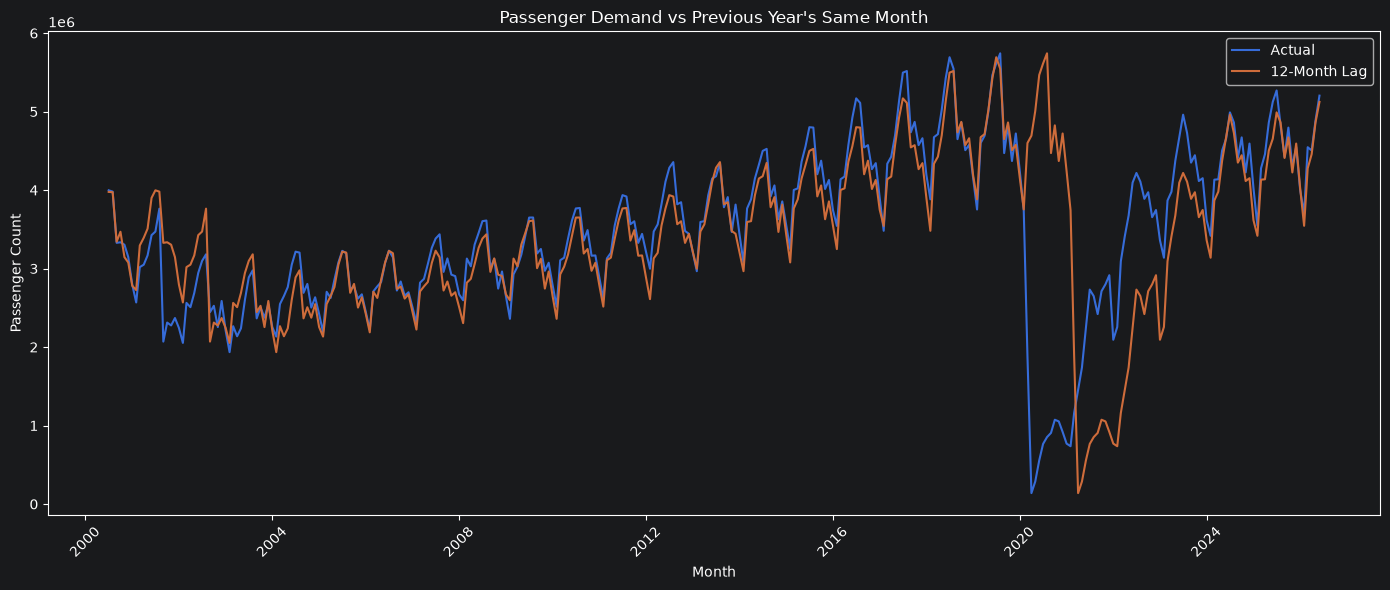

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_df["Month"],
    monthly_df["Passenger Count"],
    label="Actual"
)

plt.plot(
    monthly_df["Month"],
    monthly_df["Lag_12"],
    label="12-Month Lag"
)

plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.title("Passenger Demand vs Previous Year's Same Month")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_12",
    "Month_Number"
]

X = monthly_df[features]
y = monthly_df["Passenger Count"]

In [18]:
X.head()

,Lag_1,Lag_2,Lag_12,Rolling_Mean_3,Rolling_Mean_12,Month_Number
0,3900043.0,3508679.0,3976746.0,3.600446e+06,3.382044e+06,7
1,3996985.0,3900043.0,3972694.0,3.801902e+06,3.383730e+06,8
2,3980297.0,3996985.0,3341964.0,3.959108e+06,3.384364e+06,9
3,3327730.0,3980297.0,3468846.0,3.768337e+06,3.383178e+06,10
4,3335161.0,3327730.0,3145240.0,3.547729e+06,3.372037e+06,11


In [19]:
split_index = int(len(monthly_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [20]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 249
Testing rows: 63


In [21]:
print("Training period:")
print(monthly_df["Month"].iloc[:split_index].min())
print(monthly_df["Month"].iloc[:split_index].max())

print("\nTesting period:")
print(monthly_df["Month"].iloc[split_index:].min())
print(monthly_df["Month"].iloc[split_index:].max())

Training period:
2000-07-01 00:00:00
2021-03-01 00:00:00

Testing period:
2021-04-01 00:00:00
2026-06-01 00:00:00


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1.14, 0.31, 0.09, -0.61, 0.05,-2119.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Lag_1','Lag_2','Lag_12','Rolling_Mean_3','Rolling_Mean_12', 'Month_Number']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.257e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [24]:
y_pred = model.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Feature-Engineered Linear Regression MAE:", mae)
print("Feature-Engineered Linear Regression RMSE:", rmse)

Feature-Engineered Linear Regression MAE: 320793.764324061
Feature-Engineered Linear Regression RMSE: 388692.5183057389


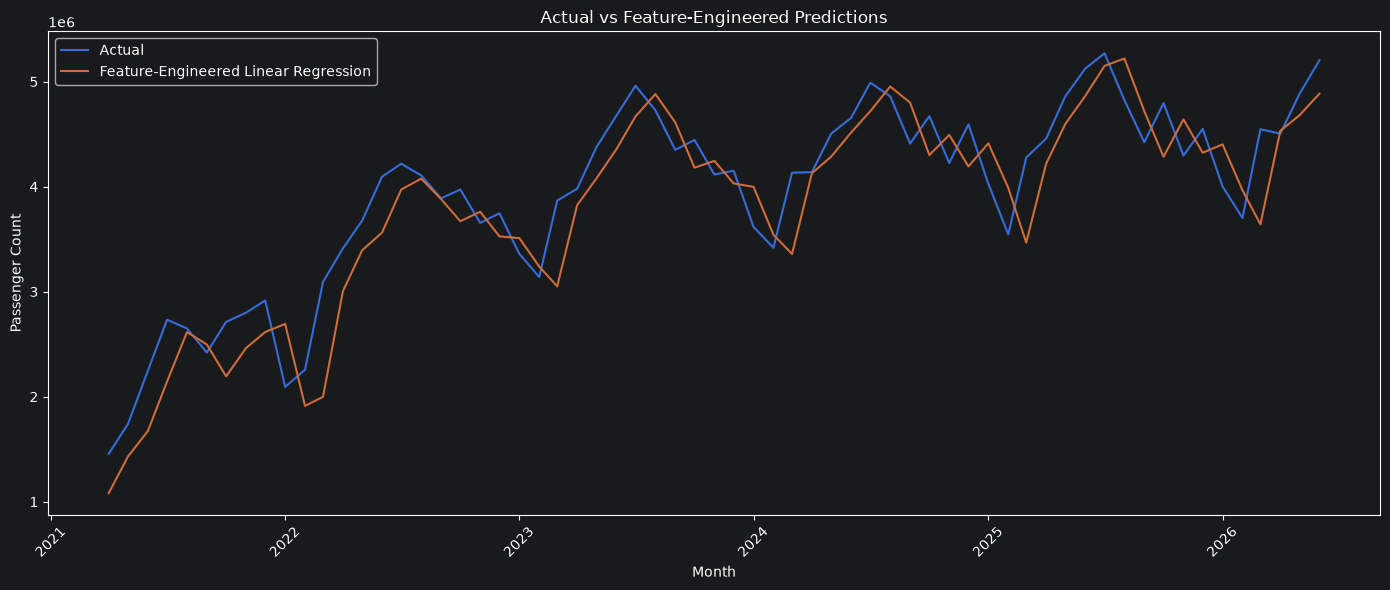

In [26]:
comparison = pd.DataFrame({
    "Month": monthly_df["Month"].iloc[split_index:],
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Month"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Month"],
    comparison["Predicted"],
    label="Feature-Engineered Linear Regression"
)

plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.title("Actual vs Feature-Engineered Predictions")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
results = pd.DataFrame({
    "Model": [
        "Previous Month Baseline",
        "Linear Regression",
        "Feature-Engineered Linear Regression"
    ],
    "MAE": [
        326970.92307692306,
        322999.101710,
        mae
    ],
    "RMSE": [
        384439.04171943024,
        377807.990227,
        rmse
    ]
})

print(results.round(2))

                                  Model        MAE       RMSE
0               Previous Month Baseline  326970.92  384439.04
1                     Linear Regression  322999.10  377807.99
2  Feature-Engineered Linear Regression  320793.76  388692.52


Day 5 Observations

1. Incorporating time-series variables such as lag variables, rolling averages, and calendar information resulted in a decrease of the MAE from 322,999.10 to 320,793.76. This is a 0.68% improvement.

2. However, RMSE increased from 377,807.99 to 388,692.52. This means the overall mean absolute error (MAE) was lower but there were a few observations with relatively high absolute errors in the model that captured the features.

3. This resulted in a model which gave mixed performance with the feature-engineered model having reduced RMSE but increased MAE when compared with the Day 4 Linear Regression model.

4. Results indicate that not all the evaluation metrics benefit from the addition of more features.

5. Linear Regression model is a feature-engineered linear regression model, but still assumes a linear relationship between the input features and passenger demand, even though it has several historical demand features.

6. The model, after feature engineering, reduced MAE by ~1.89% compared to the baseline of the previous month. This is a modest improvement, which indicates that the features currently used gives a modest improvement in average prediction error.